## Importing Libraries

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

### Training Image Preprocessing

In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 18470 files belonging to 8 classes.


2026-07-23 17:35:30.416528: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-07-23 17:35:30.416551: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-07-23 17:35:30.416557: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-07-23 17:35:30.416573: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-23 17:35:30.416584: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Validation Image Preprocessing

In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 4086 files belonging to 8 classes.


In [4]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 8), dtype=tf.float32, name=None))>

In [5]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[218.     218.     220.    ]
   [218.     218.     220.    ]
   [218.     218.     220.    ]
   ...
   [232.     235.     240.    ]
   [233.     236.     241.    ]
   [233.25   236.25   241.25  ]]

  [[218.     218.     220.    ]
   [218.     218.     220.    ]
   [218.     218.     220.    ]
   ...
   [231.75   234.75   239.75  ]
   [232.25   235.25   240.25  ]
   [233.     236.     241.    ]]

  [[218.     218.     220.    ]
   [218.     218.     220.    ]
   [218.     218.     220.    ]
   ...
   [230.75   233.75   238.75  ]
   [231.75   234.75   239.75  ]
   [232.     235.     240.    ]]

  ...

  [[200.5    199.5    195.5   ]
   [200.     199.     195.    ]
   [199.     198.     194.    ]
   ...
   [227.     232.     238.    ]
   [228.     233.     239.    ]
   [228.5    233.5    239.5   ]]

  [[200.5    199.5    195.5   ]
   [200.     199.     195.    ]
   [199.     198.     194.    ]
   ...
   [227.     232.     238.    ]
   [228.     233.     239.    ]
   [228.5  

### To avoid Overshooting

1. Choose small learning rate default 0.001 here we have taken 0.0001
2. There may be chance of underfitting so increase number of neuron
3. Add more Convolutional Layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## Building Model

In [6]:
from tensorflow.keras.layers import (
    Input,
    Dense,
    Conv2D,
    MaxPooling2D,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Sequential

In [7]:
model = Sequential()

## Building Convolution Layer

In [8]:
# Input Layer
model.add(Input(shape=(128, 128, 3)))

In [9]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=2, strides=2))

In [10]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=2,strides=2))

In [11]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=2,strides=2))

In [12]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=2,strides=2))

In [13]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=2,strides=2))

In [14]:
model.add(Dropout(0.25)) # To avoid Overfitting

In [15]:
model.add(GlobalAveragePooling2D())

In [16]:
model.add(Dense(units=1700,activation='relu'))

In [17]:
model.add(Dropout(0.4))

In [18]:
#Output Layer
model.add(Dense(units=8,activation='softmax'))

## Compiling Model

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 63, 63, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,16

 Total params: 5,605,868 (21.38 MB)

 Trainable params: 5,601,900 (21.37 MB)

 Non-trainable params: 3,968 (15.50 KB)

## Training Model

In [21]:
training_history = model.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
    ]
)

Epoch 1/10


2026-07-23 17:35:31.831607: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


578/578 ━━━━━━━━━━━━━━━━━━━━ 74s 122ms/step - accuracy: 0.6904 - loss: 0.8876 - val_accuracy: 0.8071 - val_loss: 0.4986 - learning_rate: 1.0000e-04
Epoch 2/10
578/578 ━━━━━━━━━━━━━━━━━━━━ 73s 126ms/step - accuracy: 0.8226 - loss: 0.5056 - val_accuracy: 0.8644 - val_loss: 0.4052 - learning_rate: 1.0000e-04
Epoch 3/10
578/578 ━━━━━━━━━━━━━━━━━━━━ 72s 124ms/step - accuracy: 0.8917 - loss: 0.3191 - val_accuracy: 0.8424 - val_loss: 0.5860 - learning_rate: 1.0000e-04
Epoch 4/10
578/578 ━━━━━━━━━━━━━━━━━━━━ 71s 123ms/step - accuracy: 0.9233 - loss: 0.2342 - val_accuracy: 0.9236 - val_loss: 0.2515 - learning_rate: 1.0000e-04
Epoch 5/10
578/578 ━━━━━━━━━━━━━━━━━━━━ 71s 123ms/step - accuracy: 0.9365 - loss: 0.1916 - val_accuracy: 0.9579 - val_loss: 0.1528 - learning_rate: 1.0000e-04
Epoch 6/10
578/578 ━━━━━━━━━━━━━━━━━━━━ 73s 126ms/step - accuracy: 0.9455 - loss: 0.1668 - val_accuracy: 0.8306 - val_loss: 0.8215 - learning_rate: 1.0000e-04
Epoch 7/10
578/578 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - a

## Evaluating Model

In [22]:
# Model Evaluation on Training set
train_loss, train_acc = model.evaluate(training_set)

578/578 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9968 - loss: 0.0114


In [23]:
print(train_loss,train_acc)

0.011388721875846386 0.9967514872550964


In [24]:
# Model on Validation set
val_loss, val_acc = model.evaluate(validation_set)

128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9912 - loss: 0.0502


In [25]:
print(val_loss, val_acc)

0.05019863694906235 0.9911894202232361


## Saving Model

In [26]:
model.save("tea_trained_model.keras")

In [27]:
training_history.history

{'accuracy': [0.6904168725013733,
  0.822577178478241,
  0.8916621804237366,
  0.9233351349830627,
  0.9364916086196899,
  0.945533275604248,
  0.9566864967346191,
  0.984244704246521,
  0.986139714717865,
  0.9859772324562073],
 'loss': [0.8875541687011719,
  0.5055660605430603,
  0.3191175162792206,
  0.23422043025493622,
  0.19159835577011108,
  0.1668228954076767,
  0.13444797694683075,
  0.047152988612651825,
  0.039690010249614716,
  0.041199568659067154],
 'val_accuracy': [0.8071463704109192,
  0.8644150495529175,
  0.8423886299133301,
  0.9236416816711426,
  0.9579050540924072,
  0.8306412100791931,
  0.9574155807495117,
  0.986294686794281,
  0.9911894202232361,
  0.9833577871322632],
 'val_loss': [0.49862974882125854,
  0.4052267074584961,
  0.5859739184379578,
  0.25154274702072144,
  0.15276016294956207,
  0.8215083479881287,
  0.15778373181819916,
  0.060504116117954254,
  0.050198640674352646,
  0.07357551902532578],
 'learning_rate': [9.999999747378752e-05,
  9.999999747

In [28]:
# Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [29]:
training_history.history['accuracy']

[0.6904168725013733,
 0.822577178478241,
 0.8916621804237366,
 0.9233351349830627,
 0.9364916086196899,
 0.945533275604248,
 0.9566864967346191,
 0.984244704246521,
 0.986139714717865,
 0.9859772324562073]

In [30]:
training_history.history['val_accuracy']

[0.8071463704109192,
 0.8644150495529175,
 0.8423886299133301,
 0.9236416816711426,
 0.9579050540924072,
 0.8306412100791931,
 0.9574155807495117,
 0.986294686794281,
 0.9911894202232361,
 0.9833577871322632]

## Accuracy Visualization

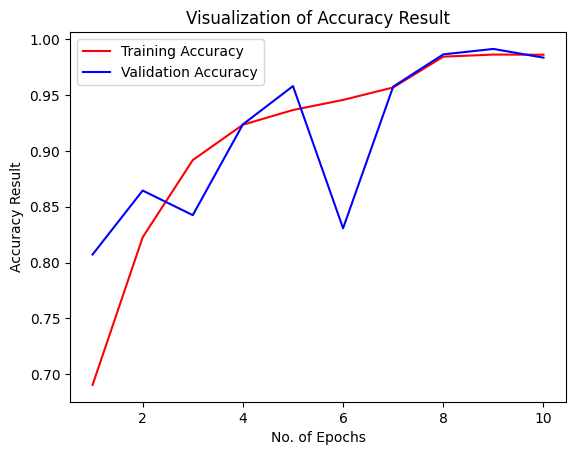

In [31]:
epochs = [i for i in range (1,11)]
plt.plot(epochs, training_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

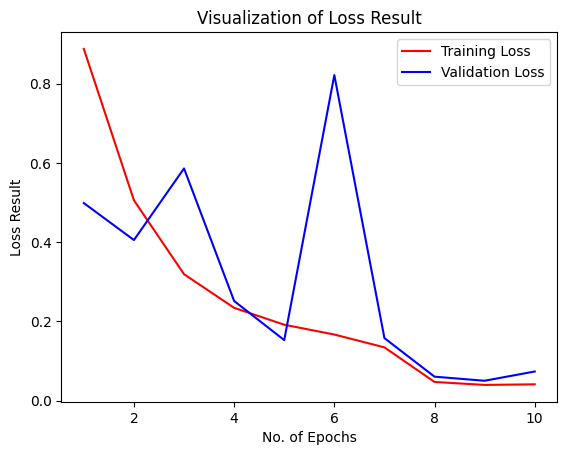

In [32]:
epochs = [i for i in range (1,11)]
plt.plot(epochs, training_history.history['loss'], color='red', label='Training Loss')
plt.plot(epochs, training_history.history['val_loss'], color='blue', label='Validation Loss')
plt.xlabel("No. of Epochs")
plt.ylabel("Loss Result")
plt.title("Visualization of Loss Result")
plt.legend()
plt.show()

## Some other metrics for model evaluation

In [33]:
class_name = validation_set.class_names
class_name

['Anthracnose',
 'algal leaf',
 'bird eye spot',
 'brown blight',
 'gray light',
 'healthy',
 'red leaf spot',
 'white spot']

In [34]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 4188 files belonging to 8 classes.


In [35]:
y_pred = model.predict(test_set)
y_pred, y_pred.shape

131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step


(array([[4.9929071e-02, 5.5286414e-06, 9.5006472e-01, ..., 1.3974325e-07,
         1.8520635e-07, 5.2098872e-09],
        [4.9929071e-02, 5.5286414e-06, 9.5006472e-01, ..., 1.3974325e-07,
         1.8520635e-07, 5.2098872e-09],
        [1.5539765e-01, 1.1541273e-04, 8.4446865e-01, ..., 5.8919932e-06,
         3.7178984e-06, 5.9178412e-08],
        ...,
        [2.2198326e-06, 1.5394653e-01, 6.2368108e-06, ..., 2.6078132e-08,
         5.8945134e-06, 2.9411671e-01],
        [1.5431121e-08, 9.3639141e-01, 2.0179943e-08, ..., 7.3315293e-10,
         1.7861364e-04, 5.8152182e-03],
        [1.5431121e-08, 9.3639141e-01, 2.0179943e-08, ..., 7.3315293e-10,
         1.7861364e-04, 5.8152182e-03]], dtype=float32),
 (4188, 8))

In [36]:
predicted_categories = tf.argmax(y_pred, axis=1)
predicted_categories

<tf.Tensor: shape=(4188,), dtype=int64, numpy=array([2, 2, 2, ..., 3, 1, 1])>

In [37]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
true_categories

2026-07-23 17:47:56.513088: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


<tf.Tensor: shape=(4188, 8), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [38]:
Y_true = tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(4188,), dtype=int64, numpy=array([0, 0, 0, ..., 7, 7, 7])>

In [39]:
!pip install scikit-learn

In [40]:
from sklearn.metrics import classification_report, confusion_matrix

In [41]:
print(classification_report(Y_true, predicted_categories, target_names=class_name))

               precision    recall  f1-score   support

  Anthracnose       0.92      0.82      0.87       578
   algal leaf       1.00      0.97      0.99       472
bird eye spot       0.93      0.98      0.96       470
 brown blight       0.99      0.97      0.98       420
   gray light       0.91      0.97      0.94       702
      healthy       0.97      0.98      0.97      1022
red leaf spot       1.00      1.00      1.00       472
   white spot       0.82      0.88      0.85        52

     accuracy                           0.95      4188
    macro avg       0.94      0.95      0.94      4188
 weighted avg       0.96      0.95      0.95      4188



In [42]:
cm = confusion_matrix(Y_true, predicted_categories)
cm

array([[474,   0,  30,   0,  56,  16,   2,   0],
       [  0, 460,   0,   2,   2,   4,   0,   4],
       [ 10,   0, 460,   0,   0,   0,   0,   0],
       [  0,   0,   0, 406,   8,   0,   0,   6],
       [ 10,   0,   2,   0, 682,   8,   0,   0],
       [ 22,   0,   0,   0,   2, 998,   0,   0],
       [  0,   0,   0,   0,   0,   0, 472,   0],
       [  0,   2,   0,   2,   2,   0,   0,  46]])

## Confusion Matrix Visualiation

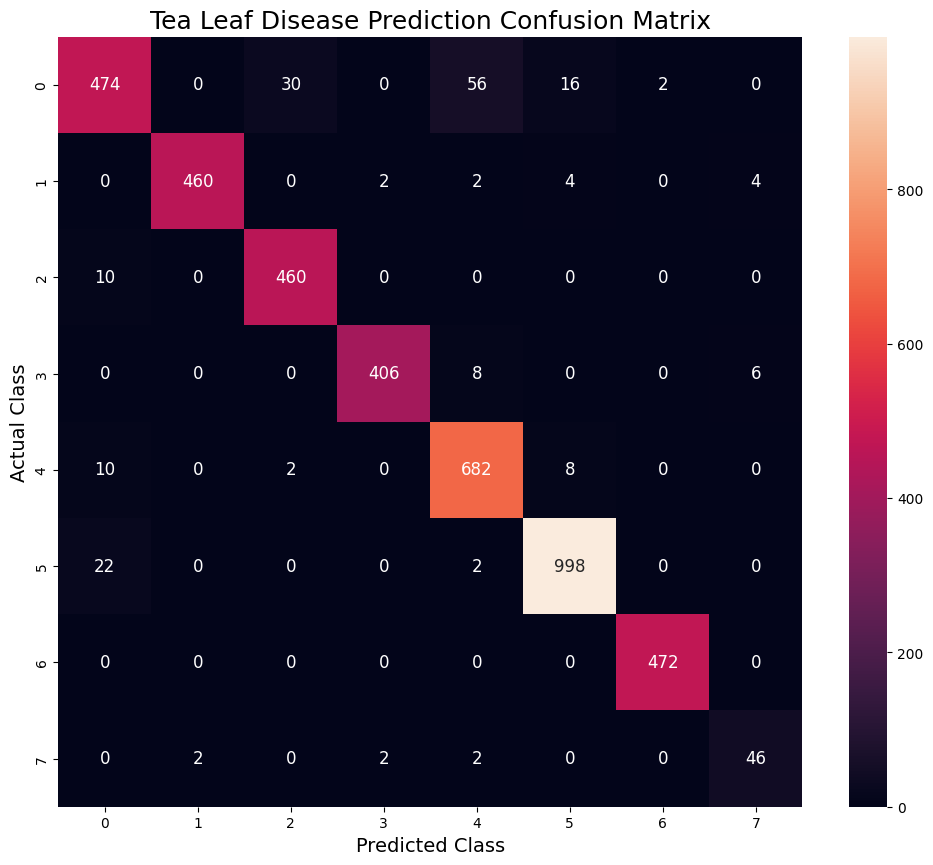

In [43]:
plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    annot_kws={"size": 12}
)
plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("Actual Class", fontsize=14)
plt.title("Tea Leaf Disease Prediction Confusion Matrix", fontsize=18)
plt.show()